Imporing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pymannkendall as mk
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import geopandas as gpd
from scipy.stats import pearsonr

Importing Political boundaries to be used as background for some plots

In [31]:
shapefile_path = r"C:\Users\Karan\Desktop\Climate_Change_NWH\data\NWH_States_Shapefile\NWH_states.shp"       # <-- change this to your actual file
nwh = gpd.read_file(shapefile_path)

print("Shapefile CRS:", nwh.crs)

# --------------------------------------------------
# 2. Make sure the shapefile uses latitude/longitude
# --------------------------------------------------
if nwh.crs != "EPSG:4326":
    nwh = nwh.to_crs("EPSG:4326")

Shapefile CRS: EPSG:3857


Importing Data

In [ ]:
BC = pd.read_csv("adress_to_your_BC_file.csv")  # <-- change this to your actual file
SU = pd.read_csv("adress_to_your_SU_file.csv")  # <-- change this to your actual file
T2 = pd.read_csv("adress_to_your_T2_file.csv")  # <-- change this to your actual file


Inspecting some Data - BC AOD

In [3]:
BC.head()

,lat,lon,1980-01,1980-02,1980-03,1980-04,1980-05,1980-06,1980-07,1980-08,...,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
0,28.0,70.000,0.007009,0.007782,0.008025,0.007588,0.005439,0.005354,0.007852,0.006612,...,0.022715,0.016177,0.015205,0.009731,0.013187,0.012601,0.015843,0.023096,0.086527,0.056904
1,28.0,70.625,0.007011,0.007896,0.008447,0.007989,0.005694,0.005334,0.007922,0.006641,...,0.021680,0.015750,0.015020,0.009243,0.013260,0.012181,0.015356,0.021393,0.084844,0.050912
2,28.0,71.250,0.007000,0.008000,0.008926,0.008637,0.006115,0.005383,0.008037,0.006616,...,0.020030,0.015239,0.014826,0.009080,0.013374,0.011933,0.015204,0.019718,0.082185,0.045506
3,28.0,71.875,0.007133,0.008018,0.009164,0.008957,0.006497,0.005560,0.008159,0.006602,...,0.018482,0.014757,0.014625,0.009177,0.013326,0.011850,0.015316,0.018661,0.079412,0.041115
4,28.0,72.500,0.007249,0.008069,0.009403,0.009397,0.006838,0.005843,0.008242,0.006664,...,0.017823,0.014122,0.014264,0.009545,0.013339,0.011863,0.015580,0.018057,0.076813,0.036779


In [4]:
BC.shape

(361, 530)

In [5]:
BC.info()
print('duration ranges from : ',BC.columns[2],' to ',BC.columns[-1])
print('lat ranges from : ',BC.iloc[0,0],' to ',BC.iloc[-1,0])
print('lat ranges from : ',BC.iloc[0,1],' to ',BC.iloc[18,1])
print("Same is the case for SU, DU and T2")

<class 'pandas.DataFrame'>
RangeIndex: 361 entries, 0 to 360
Columns: 530 entries, lat to 2023-12
dtypes: float64(530)
memory usage: 1.5 MB
duration ranges from :  1980-01  to  2023-12
lat ranges from :  28.0  to  37.0
lat ranges from :  70.0  to  81.25
Same is the case for SU, DU and T2


Checking for Null values

In [ ]:
print("Any null value present : ", BC.isna().values.any())

SU AOD

In [6]:
SU.head()

,lat,lon,1980-01,1980-02,1980-03,1980-04,1980-05,1980-06,1980-07,1980-08,...,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
0,28.0,70.000,0.020071,0.034484,0.029752,0.021402,0.023325,0.030715,0.065058,0.056597,...,0.142797,0.102088,0.106121,0.091326,0.130718,0.104201,0.096423,0.150775,0.411814,0.225702
1,28.0,70.625,0.019615,0.033681,0.029184,0.020980,0.022842,0.029925,0.065476,0.056758,...,0.138604,0.101072,0.106317,0.089006,0.135174,0.106492,0.094280,0.145405,0.414151,0.203147
2,28.0,71.250,0.019276,0.032850,0.028637,0.020744,0.022525,0.029761,0.066004,0.056303,...,0.130883,0.098293,0.106601,0.088936,0.141264,0.108703,0.094708,0.139128,0.411047,0.181666
3,28.0,71.875,0.019069,0.032095,0.028146,0.020464,0.022443,0.030354,0.066343,0.055869,...,0.121648,0.093321,0.105686,0.090522,0.140038,0.109789,0.095346,0.135088,0.400616,0.164532
4,28.0,72.500,0.018971,0.031392,0.027606,0.020120,0.022542,0.031536,0.066693,0.055910,...,0.119309,0.087845,0.103523,0.094111,0.134408,0.109712,0.098065,0.132676,0.390440,0.150141


In [7]:
print("Any null value present : ", SU.isna().values.any())

Any null value present :  False


T2m

In [8]:
T2.head()

,lat,lon,1980-01,1980-02,1980-03,1980-04,1980-05,1980-06,1980-07,1980-08,...,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
0,28.0,70.000,15.15292,19.52694,23.43853,33.14645,36.66960,38.73010,37.63085,35.50765,...,25.89590,29.34347,33.21810,35.83860,35.17983,33.91810,34.67380,29.79675,23.28414,18.14126
1,28.0,70.625,14.90194,19.22790,23.09646,33.01418,36.37985,38.36060,36.86540,34.98904,...,25.75823,29.57740,33.22756,35.23205,34.50784,33.60380,34.22350,29.60864,22.87057,17.77172
2,28.0,71.250,14.77535,19.20934,23.04202,32.95257,36.22332,38.28246,36.24392,34.66387,...,25.82660,29.87664,33.20352,34.80706,33.88995,33.38662,34.11215,29.56368,22.70930,17.67132
3,28.0,71.875,14.67030,19.27014,23.10140,32.84100,36.06054,38.19940,35.92416,34.57420,...,25.78770,29.92684,33.08462,34.41384,33.48766,33.24923,33.75695,29.41720,22.53735,17.67773
4,28.0,72.500,14.48070,19.17925,22.98830,32.52392,35.66735,37.83080,35.38430,34.29220,...,25.44030,29.67877,32.75106,33.99480,32.93630,32.80730,33.04458,28.98956,22.16177,17.48058


In [9]:
print("Any null value present : ", T2.isna().values.any())

Any null value present :  False


# Visualizations - 

Averaging each quantity (BC,SU and T2) over whole time period to see overall trend.

In [17]:
dfs = {
    "BC":BC,
    "SU":SU,
    "T2":T2
}

In [18]:
BC_ = BC.iloc[0:,0:2]
BC_["average"] = BC.iloc[0:,2:].mean(axis=1)

SU_ = SU.iloc[0:,0:2]
SU_["average"] = SU.iloc[0:,2:].mean(axis=1)

T2_ = T2.iloc[0:,0:2]
T2_["average"] = T2.iloc[0:,2:].mean(axis=1)


Plotting

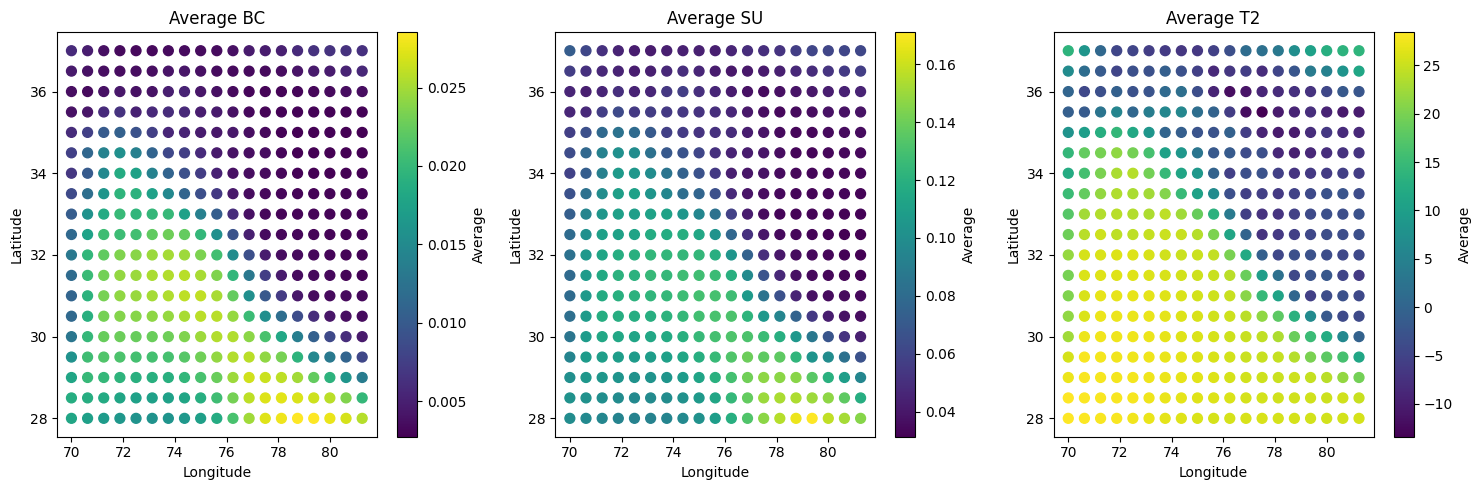

In [19]:
dfs_time_avg = {
    "BC": BC_,
    "SU": SU_,
    "T2": T2_
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

axes = axes.flatten()

for ax, (name, df) in zip(axes, dfs_time_avg.items()):

    sc = ax.scatter(
        df["lon"],
        df["lat"],
        c=df["average"],
        cmap="viridis",
        s=50
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Average {name}")

    fig.colorbar(sc, ax=ax, label="Average")

plt.tight_layout()
plt.show()

Year wise trend of Quantities averaged over whole area

In [20]:
df.columns

Index(['lat', 'lon', 'average'], dtype='str')

In [21]:
yearly_data = {}

for name, df in dfs.items():
    print(name)
    yearly_mean = {}

    # Years: 1980 to 2023
    start_year_month = df.columns[2]
    end_year_month = df.columns[-1]

    start_year, start_month = start_year_month.split('-')
    start_year = int(start_year)

    end_year, end_month = end_year_month.split('-')
    end_year = int(end_year)
    for year in range(start_year, end_year + 1):

        # Columns for the 12 months of this year
        year_cols = [
            f"{year}-{month:02d}"
            for month in range(1, 13)
        ]

        # Mean over:
        #   1. the 12 months
        #   2. all spatial locations
        try:
            yearly_mean[year] = df[year_cols].mean().mean()
        except:
            print(f"{name} has some data missing")

    yearly_data[name] = pd.Series(yearly_mean)


# ============================================================
# 3. PUT EVERYTHING INTO ONE DATAFRAME
# ============================================================

yearly_df = pd.DataFrame(yearly_data)

yearly_df.index.name = "Year"

print(yearly_df.head())
print(yearly_df.tail())

BC
SU
T2
            BC        SU         T2
Year                               
1980  0.005583  0.033102  11.416450
1981  0.005613  0.043911  10.899094
1982  0.005861  0.126475  10.384865
1983  0.006252  0.110641  10.792727
1984  0.005896  0.069997  11.358779
            BC        SU         T2
Year                               
2019  0.015161  0.095403  10.811984
2020  0.015982  0.092138  10.304390
2021  0.017337  0.090259  11.210657
2022  0.015450  0.087804  11.621805
2023  0.015924  0.096367  11.366092


Plotting

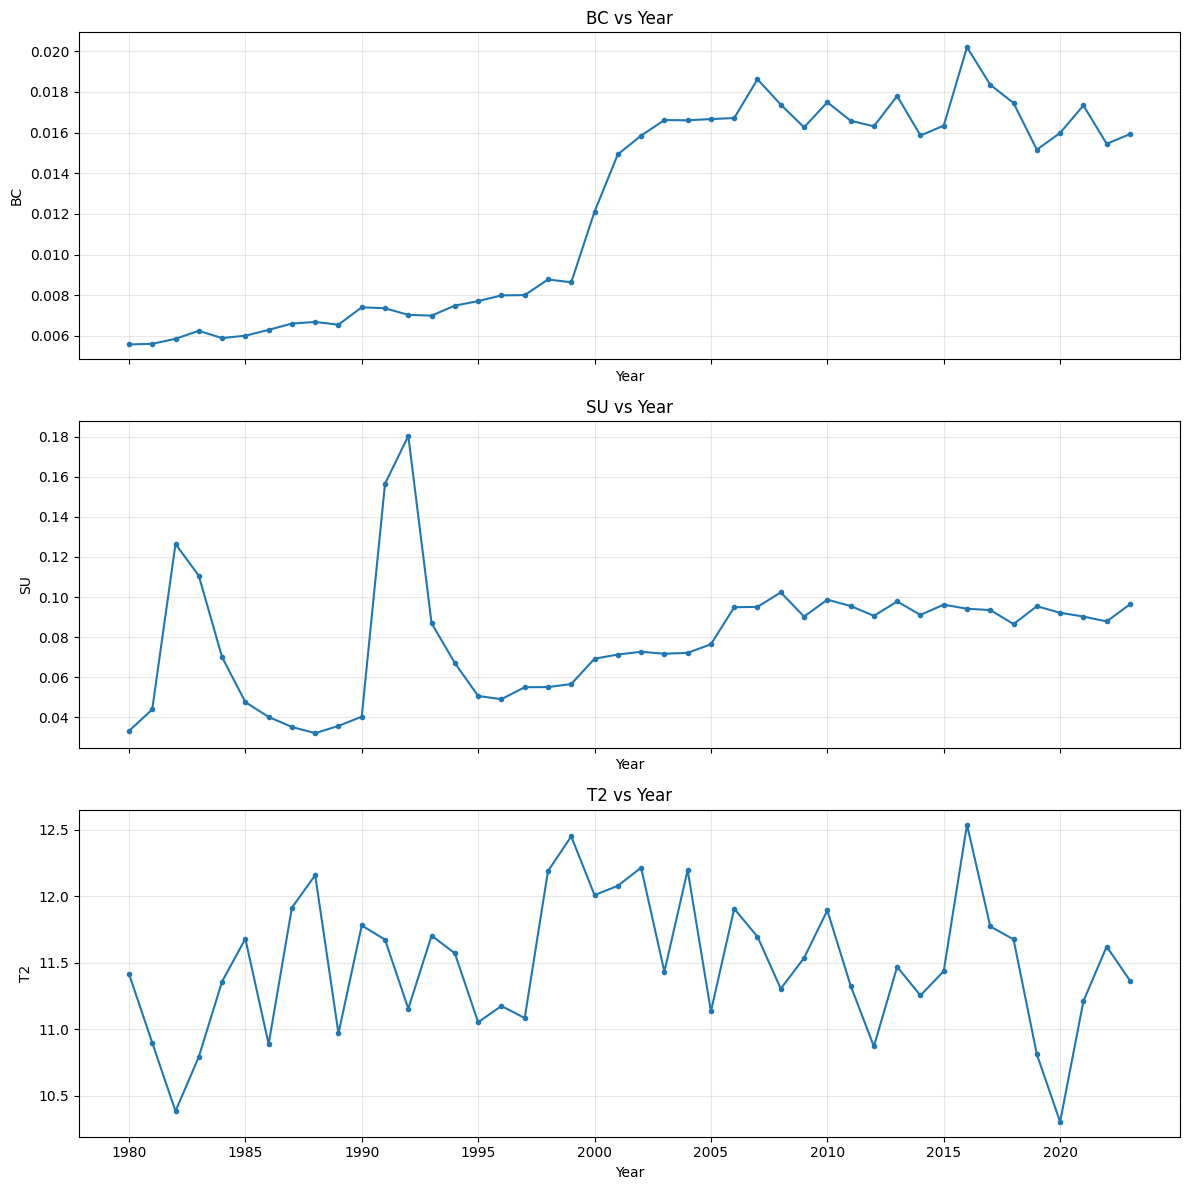

In [23]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 12),
    sharex=True
)

axes = axes.flatten()

for ax, quantity in zip(axes, yearly_df.columns):

    ax.plot(
        yearly_df.index,
        yearly_df[quantity],
        marker="o",
        markersize=3,
        linewidth=1.5
    )

    ax.set_title(f"{quantity} vs Year")
    ax.set_ylabel(quantity)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Year")

    ax.set_xticks(range(1980, 2024, 5))


axes[-2].set_xlabel("Year")

plt.tight_layout()
plt.show()

Man Kendall and Sen's Slope for T2 time series for statistically significant spatial locations only.

In [25]:
import numpy as np
import pandas as pd



# ============================================================
# 1. DEFINE SEASONS
# ============================================================

seasons = {
    "Winter": [12, 1, 2],
    "Pre-Monsoon": [3, 4, 5],
    "Monsoon": [6, 7, 8, 9],
    "Post-Monsoon": [10, 11],
    "Overall": list(range(1, 13))  # All months for overall trend
}


# ============================================================
# 2. YEAR RANGE
# ============================================================

start_year = 1980
end_year = 2023


# ============================================================
# 3. CALCULATE MK + SEN'S SLOPE AT EACH GRID POINT
# ============================================================

results = []

for idx, row in T2.iterrows():

    lat = row["lat"]
    lon = row["lon"]

    # ========================================================
    # 3A. OVERALL ANNUAL TREND
    # ========================================================

    yearly_values = []

    for year in range(start_year, end_year + 1):

        # All 12 months
        year_cols = [
            f"{year}-{month:02d}"
            for month in range(1, 13)
        ]

        # Annual mean at this grid point
        yearly_values.append(
            row[year_cols].mean()
        )

    yearly_values = np.array(yearly_values)

    # Remove missing values
    valid = ~np.isnan(yearly_values)
    series = yearly_values[valid]

    if len(series) >= 3:

        mk_result = mk.original_test(series)

        results.append({
            "lat": lat,
            "lon": lon,
            "Season": "Overall",
            "Trend": mk_result.trend,
            "p-value": mk_result.p,
            "Kendall Tau": mk_result.Tau,
            "Sen's Slope": mk_result.slope,
            "z": mk_result.z
        })


    # ========================================================
    # 3B. SEASONAL TRENDS
    # ========================================================

    for season_name, season_months in seasons.items():

        yearly_values = []

        for year in range(start_year, end_year + 1):

            year_cols = []

            for month in season_months:

                if month < 10:
                    col = f"{year}-0{month}"
                else:
                    col = f"{year}-{month}"

                year_cols.append(col)

            # Seasonal mean at this grid point
            seasonal_value = row[year_cols].mean()

            yearly_values.append(seasonal_value)

        yearly_values = np.array(yearly_values)

        # Remove missing values
        valid = ~np.isnan(yearly_values)
        series = yearly_values[valid]

        if len(series) < 3:
            continue

        # Mann-Kendall test
        mk_result = mk.original_test(series)

        results.append({
            "lat": lat,
            "lon": lon,
            "Season": season_name,
            "Trend": mk_result.trend,
            "p-value": mk_result.p,
            "Kendall Tau": mk_result.Tau,
            "Sen's Slope": mk_result.slope,
            "z": mk_result.z
        })


# ============================================================
# 4. RESULTS DATAFRAME
# ============================================================

T2_MK_grid = pd.DataFrame(results)

print(T2_MK_grid.head())

print("\nNumber of results:", len(T2_MK_grid))

    lat   lon        Season     Trend   p-value  Kendall Tau  Sen's Slope  \
0  28.0  70.0       Overall  no trend  0.911413    -0.012685    -0.001066   
1  28.0  70.0        Winter  no trend  0.943557     0.008457     0.001250   
2  28.0  70.0   Pre-Monsoon  no trend  0.221018     0.128964     0.019185   
3  28.0  70.0       Monsoon  no trend  0.099225    -0.173362    -0.013350   
4  28.0  70.0  Post-Monsoon  no trend  0.991930     0.002114     0.000228   

          z  
0 -0.111257  
1  0.070800  
2  1.223826  
3 -1.648625  
4  0.010114  

Number of results: 2166


Plotting Overall trend and seasonal too

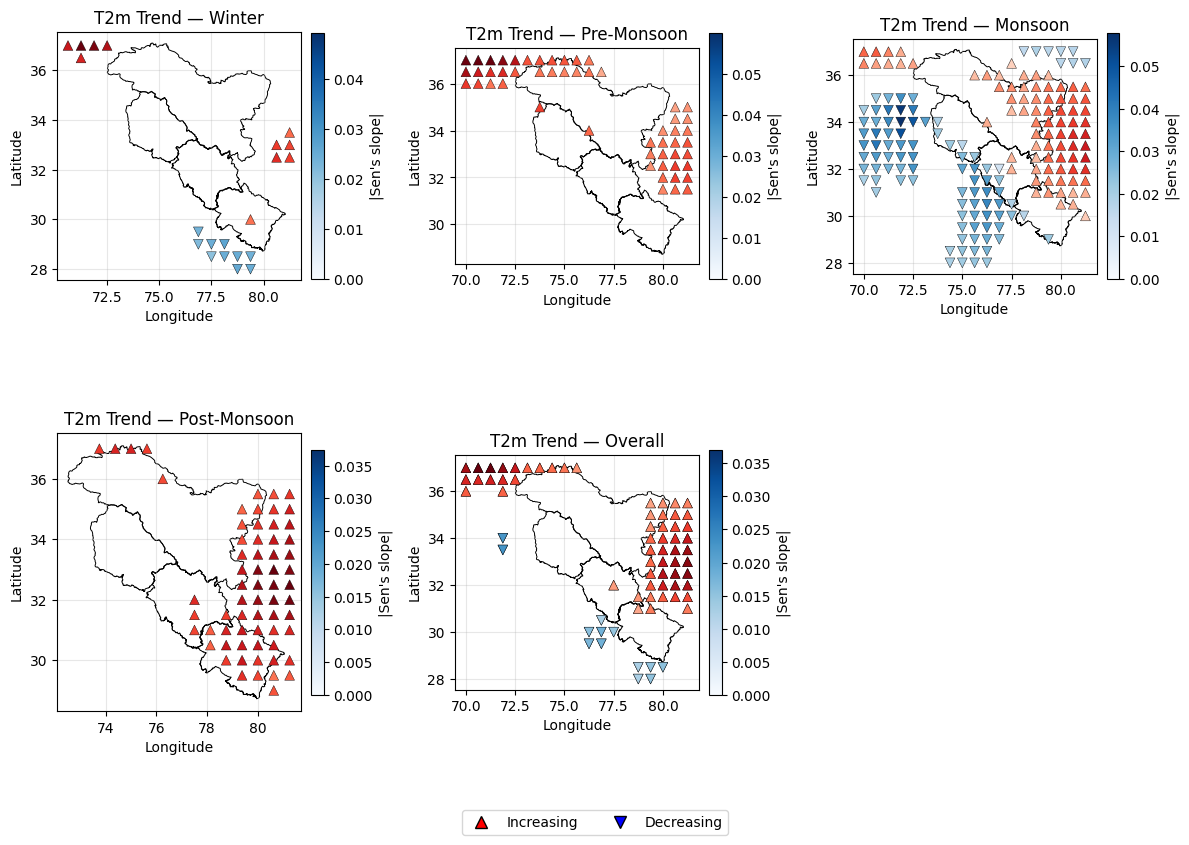

In [ ]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(12, 9)
)

axes = axes.flatten()

# ------------------------------------------------------------
# Plot the 5 seasons
# ------------------------------------------------------------
for ax, season_name in zip(axes, seasons.keys()):

    season_data = T2_MK_grid[
        T2_MK_grid["Season"] == season_name
    ].copy()

    # --------------------------------------------------------
    # Keep ONLY statistically significant trends
    # --------------------------------------------------------
    significant = season_data[
        season_data["p-value"] < 0.05
    ].copy()

    # Increasing trends
    increasing = significant[
        significant["Sen's Slope"] > 0
    ]

    # Decreasing trends
    decreasing = significant[
        significant["Sen's Slope"] < 0
    ]

    # --------------------------------------------------------
    # Plot NWH political boundaries FIRST
    # --------------------------------------------------------
    nwh.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.7,
        zorder=1
    )

    # --------------------------------------------------------
    # Common color scale
    # --------------------------------------------------------
    if len(significant) > 0:

        max_slope = significant["Sen's Slope"].abs().max()

        norm = Normalize(
            vmin=0,
            vmax=max_slope
        )

        # ----------------------------------------------------
        # Increasing trends → upward triangles → RED
        # ----------------------------------------------------
        ax.scatter(
            increasing["lon"],
            increasing["lat"],
            c=increasing["Sen's Slope"].abs(),
            cmap="Reds",
            norm=norm,
            marker="^",
            s=50,
            edgecolor="black",
            linewidth=0.3,
            zorder=2
        )

        # ----------------------------------------------------
        # Decreasing trends → downward triangles → BLUE
        # ----------------------------------------------------
        ax.scatter(
            decreasing["lon"],
            decreasing["lat"],
            c=decreasing["Sen's Slope"].abs(),
            cmap="Blues",
            norm=norm,
            marker="v",
            s=50,
            edgecolor="black",
            linewidth=0.3,
            zorder=2
        )

        # ----------------------------------------------------
        # Colorbar
        # ----------------------------------------------------
        sm = ScalarMappable(
            norm=norm,
            cmap="Blues"
        )

        sm.set_array([])

        cbar = fig.colorbar(
            sm,
            ax=ax,
            fraction=0.046,
            pad=0.04
        )

        cbar.set_label("|Sen's slope|")

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_title(f"T2m Trend — {season_name}")

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.grid(True, alpha=0.3)


# ============================================================
# DELETE EMPTY 6TH SUBPLOT
# ============================================================

fig.delaxes(axes[5])


# ============================================================
# ONE COMMON LEGEND FOR ALL 5 PLOTS
# ============================================================

increasing_handle = Line2D(
    [0], [0],
    marker="^",
    color="w",
    markerfacecolor="red",
    markeredgecolor="black",
    markersize=9,
    label="Increasing"
)

decreasing_handle = Line2D(
    [0], [0],
    marker="v",
    color="w",
    markerfacecolor="blue",
    markeredgecolor="black",
    markersize=9,
    label="Decreasing"
)

fig.legend(
    handles=[
        increasing_handle,
        decreasing_handle
    ],
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)


# Leave space for the common legend
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()

## Trying out correlating analysis to see how aerosols affect T2m

Specify start and end year - 

In [53]:
start_year = 1980
end_year = 2023

# Calculating correlations -

For T2m and BC

In [54]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# Monthly columns from 2003-01 to 2023-12
months = [
    f"{year}-{month:02d}"
    for year in range(start_year, end_year + 1)
    for month in range(1, 13)
]

results = []

for idx in range(len(T2)):

    lat = T2.loc[idx, "lat"]
    lon = T2.loc[idx, "lon"]

    # T2m and BC series at this spatial point
    t2_series = T2.loc[idx, months].values.astype(float)
    bc_series = BC.loc[idx, months].values.astype(float)

    # Remove months where either variable is missing
    valid = ~(np.isnan(t2_series) | np.isnan(bc_series))

    t2_valid = t2_series[valid]
    bc_valid = bc_series[valid]

    # Need at least 3 valid observations
    if len(t2_valid) < 3:
        continue

    # Pearson correlation
    r, p_value = pearsonr(t2_valid, bc_valid)

    results.append({
        "lat": lat,
        "lon": lon,
        "Pearson_r": r,
        "p-value": p_value,
        "N": len(t2_valid)
    })

# Convert to dataframe
T2_BC_pearson = pd.DataFrame(results)

print(T2_BC_pearson.head())
print("\nNumber of spatial points:", len(T2_BC_pearson))

    lat     lon  Pearson_r       p-value    N
0  28.0  70.000  -0.431792  2.159377e-25  528
1  28.0  70.625  -0.431645  2.250726e-25  528
2  28.0  71.250  -0.431620  2.266212e-25  528
3  28.0  71.875  -0.429077  4.620572e-25  528
4  28.0  72.500  -0.420667  4.668866e-24  528

Number of spatial points: 361


For T2m and SU

In [55]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


# Monthly columns from 2003-01 to 2023-12
months = [
    f"{year}-{month:02d}"
    for year in range(start_year, end_year + 1)
    for month in range(1, 13)
]

results = []

for idx in range(len(T2)):

    lat = T2.loc[idx, "lat"]
    lon = T2.loc[idx, "lon"]

    # T2m and SU series at this spatial point
    t2_series = T2.loc[idx, months].values.astype(float)
    su_series = SU.loc[idx, months].values.astype(float)

    # Remove months where either variable is missing
    valid = ~(np.isnan(t2_series) | np.isnan(su_series))

    t2_valid = t2_series[valid]
    su_valid = su_series[valid]

    # Need at least 3 valid observations
    if len(t2_valid) < 3:
        continue

    # Pearson correlation
    r, p_value = pearsonr(t2_valid, su_valid)

    results.append({
        "lat": lat,
        "lon": lon,
        "Pearson_r": r,
        "p-value": p_value,
        "N": len(t2_valid)
    })

# Convert to dataframe
T2_SU_pearson = pd.DataFrame(results)

print(T2_SU_pearson.head())
print("\nNumber of spatial points:", len(T2_SU_pearson))

    lat     lon  Pearson_r   p-value    N
0  28.0  70.000  -0.074722  0.086287  528
1  28.0  70.625  -0.065239  0.134361  528
2  28.0  71.250  -0.053723  0.217790  528
3  28.0  71.875  -0.036829  0.398368  528
4  28.0  72.500  -0.012758  0.769919  528

Number of spatial points: 361


Plotting for T2m and BC
1. For all points
2. Only Statistically Significant points

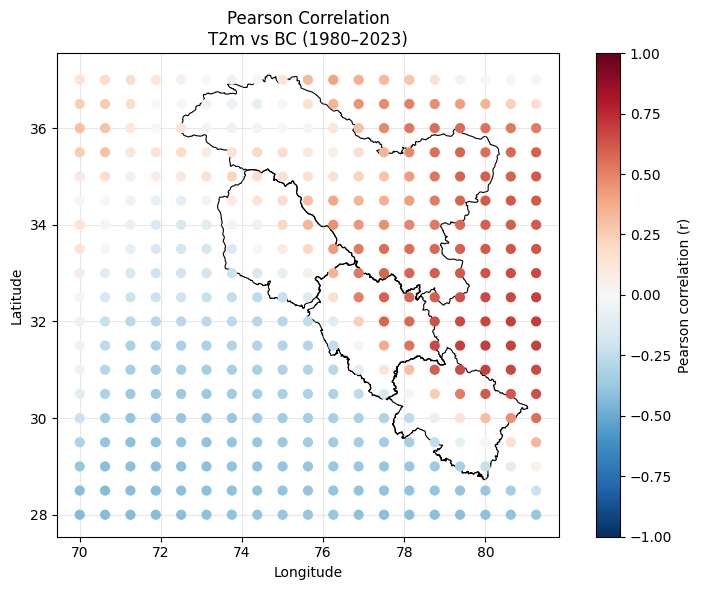

In [56]:
fig, ax = plt.subplots(figsize=(8, 6))

# --------------------------------------------------
# Plot NWH political boundaries FIRST
# --------------------------------------------------
nwh.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8,
    zorder=1
)

scatter = ax.scatter(
    T2_BC_pearson["lon"],
    T2_BC_pearson["lat"],
    c=T2_BC_pearson["Pearson_r"],
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    s=40,
    zorder=2
)

# --------------------------------------------------
# Colorbar
# --------------------------------------------------
plt.colorbar(
    scatter,
    ax=ax,
    label="Pearson correlation (r)"
)

# --------------------------------------------------
# Labels and formatting
# --------------------------------------------------
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    "Pearson Correlation\n"
    f"T2m vs BC ({start_year}–{end_year})"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

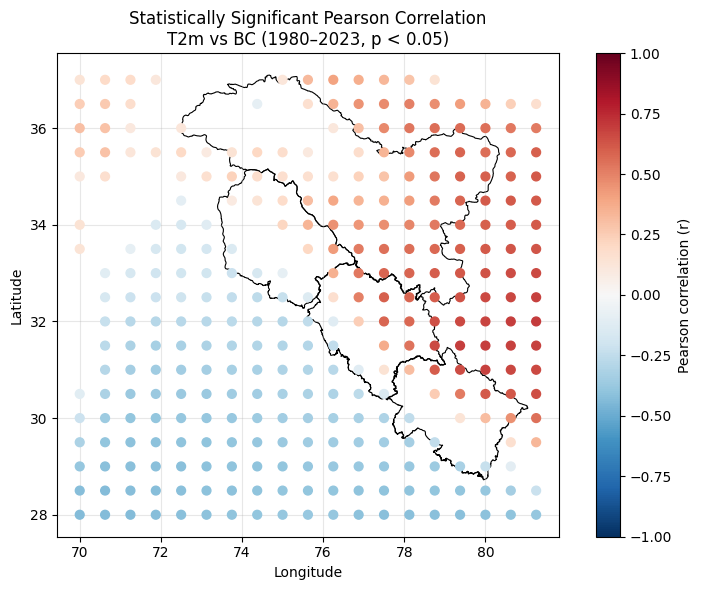

In [57]:
significant = T2_BC_pearson[
    T2_BC_pearson["p-value"] < 0.05
].copy()

# Create figure AND axes
fig, ax = plt.subplots(figsize=(8, 6))

# --------------------------------------------------
# Plot NWH political boundaries FIRST
# --------------------------------------------------
nwh.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8,
    zorder=1
)

# --------------------------------------------------
# Plot significant correlations ON TOP
# --------------------------------------------------
scatter = ax.scatter(
    significant["lon"],
    significant["lat"],
    c=significant["Pearson_r"],
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    s=40,
    zorder=2
)

# --------------------------------------------------
# Colorbar
# --------------------------------------------------
plt.colorbar(
    scatter,
    ax=ax,
    label="Pearson correlation (r)"
)

# --------------------------------------------------
# Labels and formatting
# --------------------------------------------------
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    "Statistically Significant Pearson Correlation\n"
    f"T2m vs BC ({start_year}–{end_year}, p < 0.05)"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Plotting for T2m and SU
1. For all points
2. Only Statistically Significant points

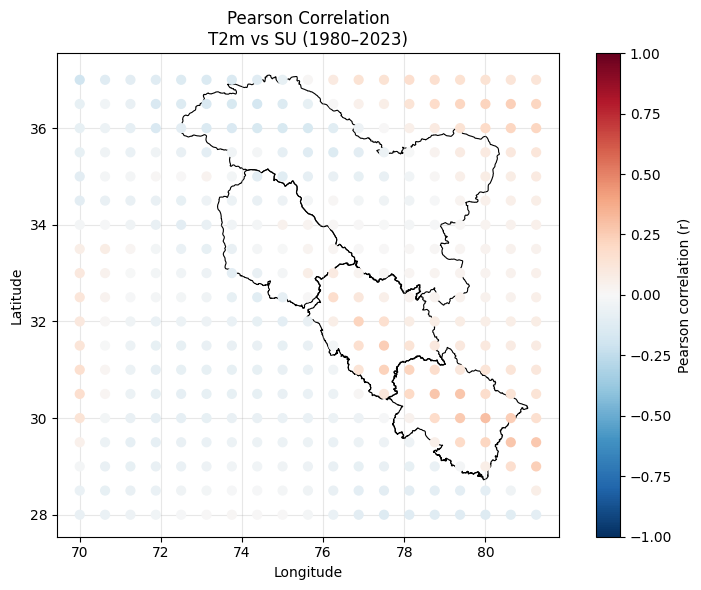

In [58]:
fig, ax = plt.subplots(figsize=(8, 6))

# --------------------------------------------------
# Plot NWH political boundaries FIRST
# --------------------------------------------------
nwh.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8,
    zorder=1
)

scatter = ax.scatter(
    T2_SU_pearson["lon"],
    T2_SU_pearson["lat"],
    c=T2_SU_pearson["Pearson_r"],
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    s=40,
    zorder=2
)

# --------------------------------------------------
# Colorbar
# --------------------------------------------------
plt.colorbar(
    scatter,
    ax=ax,
    label="Pearson correlation (r)"
)

# --------------------------------------------------
# Labels and formatting
# --------------------------------------------------
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    "Pearson Correlation\n"
    f"T2m vs SU ({start_year}–{end_year})"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

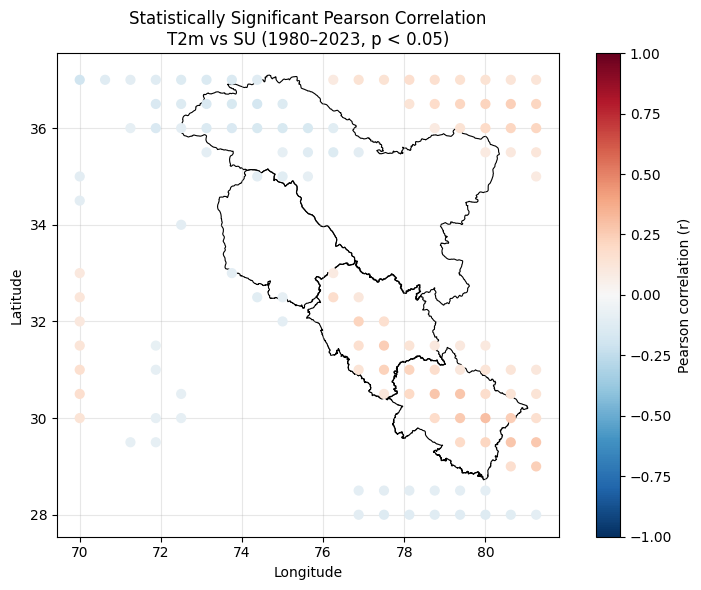

In [59]:
significant = T2_SU_pearson[
    T2_SU_pearson["p-value"] < 0.05
].copy()

# Create figure AND axes
fig, ax = plt.subplots(figsize=(8, 6))

# --------------------------------------------------
# Plot NWH political boundaries FIRST
# --------------------------------------------------
nwh.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8,
    zorder=1
)

# --------------------------------------------------
# Plot significant correlations ON TOP
# --------------------------------------------------
scatter = ax.scatter(
    significant["lon"],
    significant["lat"],
    c=significant["Pearson_r"],
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    s=40,
    zorder=2
)

# --------------------------------------------------
# Colorbar
# --------------------------------------------------
plt.colorbar(
    scatter,
    ax=ax,
    label="Pearson correlation (r)"
)

# --------------------------------------------------
# Labels and formatting
# --------------------------------------------------
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title(
    "Statistically Significant Pearson Correlation\n"
    f"T2m vs SU ({start_year}–{end_year}, p < 0.05)"
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Altitude dependent analysis

Importing Elevating data from OpenTopography

In [ ]:
import os
import requests
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds

# Specifying the latitude and longitude bounds for the region of interest (NWH)

LAT_MIN = 28.0
LAT_MAX = 37.0

LON_MIN = 70.0
LON_MAX = 81.25


# ============================================================
# 2. TARGET GRID
# ============================================================

LAT_STEP = 0.5
LON_STEP = 0.625


# ============================================================
# 3. OPENTOPOGRAPHY API KEY
# ============================================================

API_KEY = "Your Open Topography API Key Here"  # <-- change this to your actual API key


# ============================================================
# 4. SPLIT REGION INTO 3 TILES
# ============================================================

tiles = [
    {
        "name": "south",
        "south": 28.0,
        "north": 31.0,
        "west": 70.0,
        "east": 81.25
    },

    {
        "name": "middle",
        "south": 31.0,
        "north": 34.0,
        "west": 70.0,
        "east": 81.25
    },

    {
        "name": "north",
        "south": 34.0,
        "north": 37.0,
        "west": 70.0,
        "east": 81.25
    }
]


# ============================================================
# 5. DOWNLOAD FUNCTION
# ============================================================

def download_dem(tile):

    filename = f"NWH_COP30_{tile['name']}.tif"

    if os.path.exists(filename):
        print(f"\n{filename} already exists.")
        print("Skipping download.")
        return filename

    url = (
        "https://portal.opentopography.org/API/globaldem"
        f"?demtype=COP30"
        f"&south={tile['south']}"
        f"&north={tile['north']}"
        f"&west={tile['west']}"
        f"&east={tile['east']}"
        f"&outputFormat=GTiff"
        f"&API_Key={API_KEY}"
    )

    print("\n============================================")
    print(f"Downloading {tile['name']} tile")
    print("============================================")

    print(
        f"Latitude : {tile['south']} → {tile['north']}"
    )

    print(
        f"Longitude: {tile['west']} → {tile['east']}"
    )

    response = requests.get(url)

    if response.status_code != 200:

        print("\nDOWNLOAD FAILED")
        print(response.text[:1000])

        raise RuntimeError(
            f"Failed to download {tile['name']} tile."
        )

    # Make sure we actually received a TIFF
    content_type = response.headers.get(
        "Content-Type",
        ""
    )

    if "xml" in content_type.lower():

        print(response.text[:1000])

        raise RuntimeError(
            "OpenTopography returned an error instead "
            "of a GeoTIFF."
        )

    with open(filename, "wb") as f:
        f.write(response.content)

    print(f"\nSaved: {filename}")

    return filename


# ============================================================
# 6. DOWNLOAD ALL THREE TILES
# ============================================================

dem_files = []

for tile in tiles:

    filename = download_dem(tile)

    dem_files.append(filename)


# ============================================================
# 7. CREATE TARGET CLIMATE GRID
# ============================================================

latitudes = np.arange(
    LAT_MIN,
    LAT_MAX + LAT_STEP / 2,
    LAT_STEP
)

longitudes = np.arange(
    LON_MIN,
    LON_MAX + LON_STEP / 2,
    LON_STEP
)


# ============================================================
# 8. FUNCTION TO EXTRACT ELEVATION
# ============================================================

def get_cell_elevation(src, lat, lon):

    # --------------------------------------------------------
    # Grid-cell boundaries
    # --------------------------------------------------------

    cell_lat_min = lat - LAT_STEP / 2
    cell_lat_max = lat + LAT_STEP / 2

    cell_lon_min = lon - LON_STEP / 2
    cell_lon_max = lon + LON_STEP / 2


    # --------------------------------------------------------
    # Check if cell intersects DEM
    # --------------------------------------------------------

    if (
        cell_lat_max <= src.bounds.bottom
        or cell_lat_min >= src.bounds.top
        or cell_lon_max <= src.bounds.left
        or cell_lon_min >= src.bounds.right
    ):
        return None


    # --------------------------------------------------------
    # Clip cell to DEM boundaries
    # --------------------------------------------------------

    cell_lat_min = max(
        cell_lat_min,
        src.bounds.bottom
    )

    cell_lat_max = min(
        cell_lat_max,
        src.bounds.top
    )

    cell_lon_min = max(
        cell_lon_min,
        src.bounds.left
    )

    cell_lon_max = min(
        cell_lon_max,
        src.bounds.right
    )


    # --------------------------------------------------------
    # Convert geographic bounds to raster window
    # --------------------------------------------------------

    window = from_bounds(
        cell_lon_min,
        cell_lat_min,
        cell_lon_max,
        cell_lat_max,
        src.transform
    )


    # --------------------------------------------------------
    # Read DEM pixels
    # --------------------------------------------------------

    data = src.read(
        1,
        window=window,
        masked=True
    )


    # --------------------------------------------------------
    # Remove NoData
    # --------------------------------------------------------

    values = data.compressed()


    if len(values) == 0:
        return None


    # --------------------------------------------------------
    # Calculate elevation statistics
    # --------------------------------------------------------

    return {
        "mean": np.mean(values),
        "median": np.median(values),
        "min": np.min(values),
        "max": np.max(values),
        "std": np.std(values)
    }


# ============================================================
# 9. PROCESS ALL THREE DEM TILES
# ============================================================

records = []


for dem_file in dem_files:

    print("\n============================================")
    print(f"Processing: {dem_file}")
    print("============================================")

    with rasterio.open(dem_file) as src:

        print("CRS        :", src.crs)
        print("Resolution :", src.res)
        print("Dimensions :", src.width, "x", src.height)
        print("Bounds     :", src.bounds)


        # ----------------------------------------------------
        # Loop through target grid
        # ----------------------------------------------------

        for lat in latitudes:

            for lon in longitudes:

                result = get_cell_elevation(
                    src,
                    lat,
                    lon
                )


                if result is None:
                    continue


                records.append({
                    "lat": lat,
                    "lon": lon,

                    "elevation_mean":
                        result["mean"],

                    "elevation_median":
                        result["median"],

                    "elevation_min":
                        result["min"],

                    "elevation_max":
                        result["max"],

                    "elevation_std":
                        result["std"]
                })


# ============================================================
# 10. CREATE DATAFRAME
# ============================================================

elevation_df = pd.DataFrame(records)


# ============================================================
# 11. REMOVE DUPLICATES
# ============================================================

elevation_df = (
    elevation_df
    .drop_duplicates(
        subset=["lat", "lon"]
    )
    .sort_values(
        ["lat", "lon"]
    )
    .reset_index(drop=True)
)


# ============================================================
# 12. SAVE
# ============================================================

output_file = "NWH_elevation_0.5x0.625.csv"

elevation_df.to_csv(
    output_file,
    index=False
)


# ============================================================
# 13. SUMMARY
# ============================================================

print("\n")
print("============================================")
print("FINAL RESULT")
print("============================================")

print(
    f"Number of grid points: {len(elevation_df)}"
)

print(
    f"Latitude: "
    f"{elevation_df['lat'].min()} → "
    f"{elevation_df['lat'].max()}"
)

print(
    f"Longitude: "
    f"{elevation_df['lon'].min()} → "
    f"{elevation_df['lon'].max()}"
)

print("\nDataFrame:")
print(elevation_df.head(10))

print("\nSaved to:")
print(output_file)

In [83]:
elevation_df = pd.read_csv("NWH_elevation_0.5x0.625.csv")

In [84]:
elevation_df.head()

,lat,lon,elevation_mean,elevation_median,elevation_min,elevation_max,elevation_std
0,28.0,70.000,78.211586,77.145420,69.982850,104.51717,4.244454
1,28.0,70.625,95.992950,94.630330,72.500000,154.92514,11.796946
2,28.0,71.250,112.039760,110.174255,88.858284,161.28760,10.242769
3,28.0,71.875,122.145650,119.663440,98.803276,183.82426,11.553507
4,28.0,72.500,157.586720,156.706280,113.506480,227.08255,17.648224


Merging elevation column into T2m

In [125]:
# Keep only the columns we need from elevation data
elev = elevation_df[
    ["lat", "lon", "elevation_mean"]
].copy()

# Rename for convenience
elev = elev.rename(
    columns={"elevation_mean": "elevation"}
)

# Merge with T2_m
T2 = T2.merge(
    elev,
    on=["lat", "lon"],
    how="left"
)

print(T2.head())
print(T2.shape)

    lat     lon   1980-01   1980-02   1980-03   1980-04   1980-05   1980-06  \
0  28.0  70.000  15.15292  19.52694  23.43853  33.14645  36.66960  38.73010   
1  28.0  70.625  14.90194  19.22790  23.09646  33.01418  36.37985  38.36060   
2  28.0  71.250  14.77535  19.20934  23.04202  32.95257  36.22332  38.28246   
3  28.0  71.875  14.67030  19.27014  23.10140  32.84100  36.06054  38.19940   
4  28.0  72.500  14.48070  19.17925  22.98830  32.52392  35.66735  37.83080   

    1980-07   1980-08  ...   2023-04   2023-05   2023-06   2023-07   2023-08  \
0  37.63085  35.50765  ...  29.34347  33.21810  35.83860  35.17983  33.91810   
1  36.86540  34.98904  ...  29.57740  33.22756  35.23205  34.50784  33.60380   
2  36.24392  34.66387  ...  29.87664  33.20352  34.80706  33.88995  33.38662   
3  35.92416  34.57420  ...  29.92684  33.08462  34.41384  33.48766  33.24923   
4  35.38430  34.29220  ...  29.67877  32.75106  33.99480  32.93630  32.80730   

    2023-09   2023-10   2023-11   2023-12   

Merging all time columns (1980-01 to 2023-12) into one column

In [137]:
import pandas as pd
import numpy as np

temp_cols = [
    c for c in T2.columns
    if c not in ["lat", "lon", "elevation"]
]

T2_long = T2.melt(
    id_vars=["lat", "lon", "elevation"],
    value_vars=temp_cols,
    var_name="date",
    value_name="T2"
)

# Convert YYYY-MM to datetime
T2_long["date"] = pd.to_datetime(T2_long["date"], format="%Y-%m")

# Extract year and month
T2_long["year"] = T2_long["date"].dt.year
T2_long["month"] = T2_long["date"].dt.month

# Remove missing values
T2_long = T2_long.dropna(
    subset=["T2", "elevation"]
)

T2_long.head()

,lat,lon,elevation,date,T2,year,month
0,28.0,70.000,78.211586,1980-01-01,15.15292,1980,1
1,28.0,70.625,95.992950,1980-01-01,14.90194,1980,1
2,28.0,71.250,112.039760,1980-01-01,14.77535,1980,1
3,28.0,71.875,122.145650,1980-01-01,14.67030,1980,1
4,28.0,72.500,157.586720,1980-01-01,14.48070,1980,1


Adding column to specify decade

In [138]:
def get_period(year):

    if 1980 <= year <= 1989:
        return "1980–1989"

    elif 1990 <= year <= 1999:
        return "1990–1999"

    elif 2000 <= year <= 2009:
        return "2000–2009"

    elif 2010 <= year <= 2019:
        return "2010–2019"

    elif 2020 <= year <= 2023:
        return "2020–2023"

    return np.nan


T2_long["period"] = T2_long["year"].apply(
    get_period
)

Adding column to specify elevation range

In [139]:
elevation_bins = [
    0,
    1000,
    2000,
    3000,
    4000,
    5000,
    6000,
    8000
]

elevation_labels = [
    "0–1000 m",
    "1000–2000 m",
    "2000–3000 m",
    "3000–4000 m",
    "4000–5000 m",
    "5000–6000 m",
    "6000–8000 m"
]

T2_long["elevation_group"] = pd.cut(
    T2_long["elevation"],
    bins=elevation_bins,
    labels=elevation_labels,
    include_lowest=True
)

## Plotting PDF for spatial probability density vs T2m

1. For Lower Himalayas (1000-2000 m elevation)

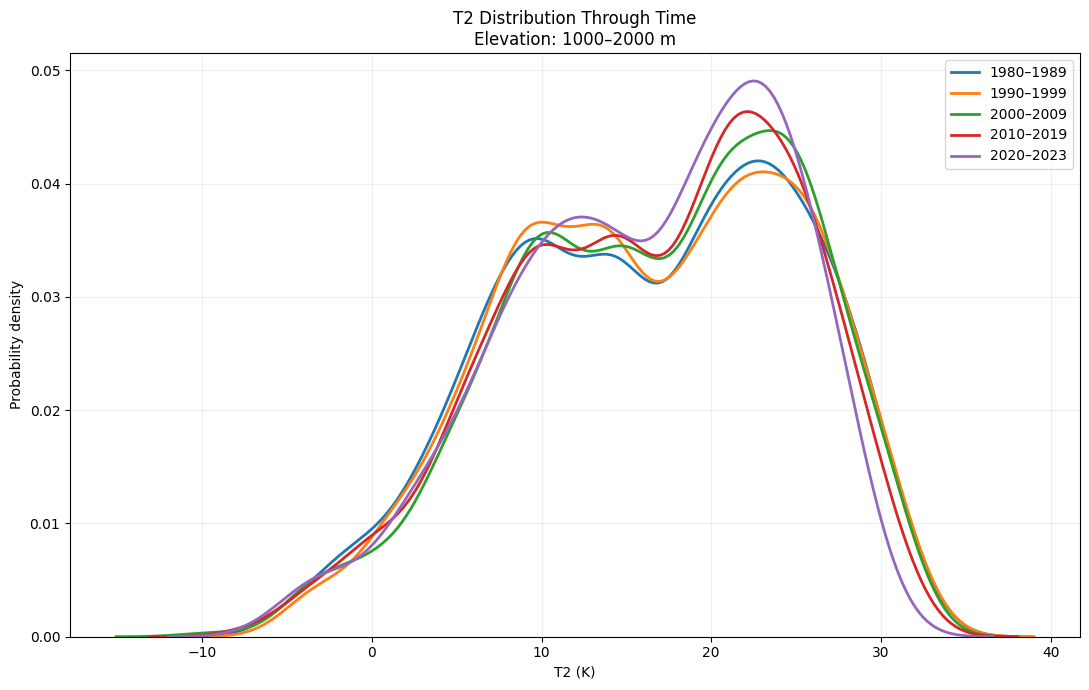

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_elevation = "1000–2000 m"

periods = [
    "1980–1989",
    "1990–1999",
    "2000–2009",
    "2010–2019",
    "2020–2023"
]

plt.figure(figsize=(11, 7))

for period in periods:

    data = T2_long.loc[
        (T2_long["elevation_group"] == selected_elevation) &
        (T2_long["period"] == period),
        "T2"
    ].dropna()

    sns.kdeplot(
        data,
        label=period,
        linewidth=2
    )

plt.xlabel("T2 (K)")
plt.ylabel("Probability density")

plt.title(
    f"T2 Distribution Through Time\n"
    f"Elevation: {selected_elevation}"
)

plt.legend()

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

2. For Upper Himalayas (5000-6000 m)

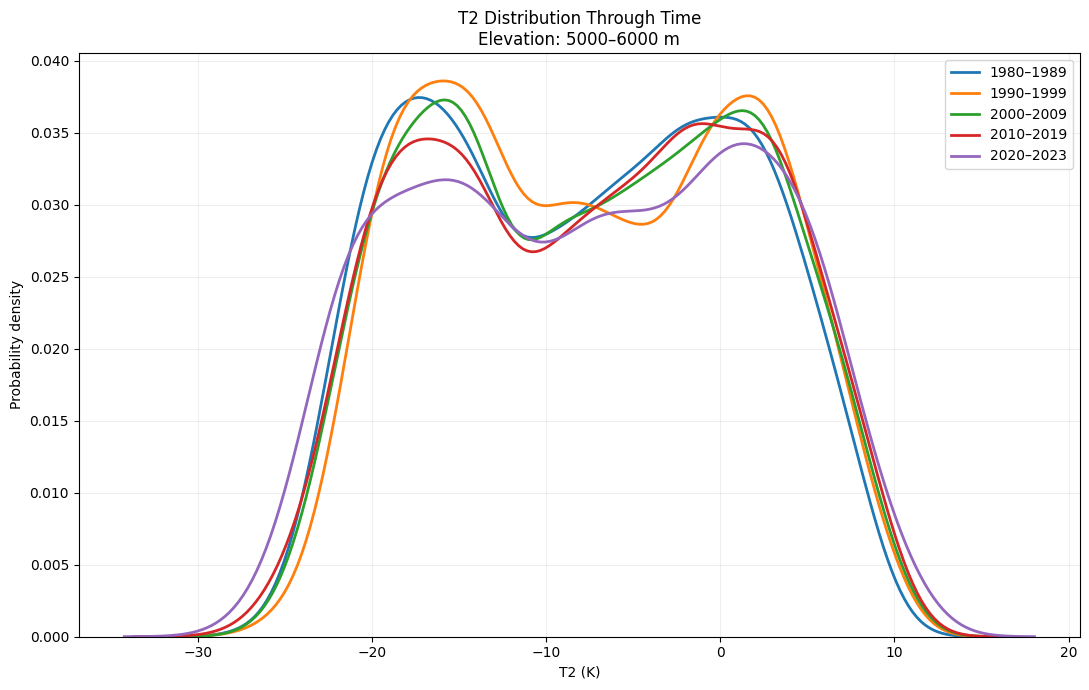

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_elevation = "5000–6000 m"

periods = [
    "1980–1989",
    "1990–1999",
    "2000–2009",
    "2010–2019",
    "2020–2023"
]

plt.figure(figsize=(11, 7))

for period in periods:

    data = T2_long.loc[
        (T2_long["elevation_group"] == selected_elevation) &
        (T2_long["period"] == period),
        "T2"
    ].dropna()

    sns.kdeplot(
        data,
        label=period,
        linewidth=2
    )

plt.xlabel("T2 (K)")
plt.ylabel("Probability density")

plt.title(
    f"T2 Distribution Through Time\n"
    f"Elevation: {selected_elevation}"
)

plt.legend()

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Detrended Correlation analysis

Specify Start and End year

In [152]:
start_year = 1980
end_year = 2023

Computing Detrended correlation for BC and SU

In [153]:
import numpy as np
import pandas as pd
from scipy.stats import linregress, pearsonr

# Monthly columns: 2003-01 to 2023-12
months = [
    f"{year}-{month:02d}"
    for year in range(start_year, end_year + 1)
    for month in range(1, 13)
]

# Aerosol datasets
aerosols = {
    "BC": BC,
    "SU": SU
}

results = []

# Loop through every spatial point
for idx in range(len(T2)):

    lat = T2.loc[idx, "lat"]
    lon = T2.loc[idx, "lon"]

    # T2m series at this pixel
    t2 = T2.loc[idx, months].values.astype(float)

    for aerosol_name, aerosol_df in aerosols.items():

        # Aerosol series at the same pixel
        aerosol = aerosol_df.loc[idx, months].values.astype(float)

        # --------------------------------------------------
        # Remove months where either series has NaN
        # --------------------------------------------------
        valid = ~(np.isnan(t2) | np.isnan(aerosol))

        t2_valid = t2[valid]
        aerosol_valid = aerosol[valid]

        if len(t2_valid) < 3:
            continue

        # --------------------------------------------------
        # Detrend T2m
        # --------------------------------------------------
        time = np.arange(len(t2_valid))

        t2_trend = linregress(time, t2_valid)

        t2_fitted = (
            t2_trend.slope * time
            + t2_trend.intercept
        )

        t2_residual = t2_valid - t2_fitted

        # --------------------------------------------------
        # Detrend aerosol
        # --------------------------------------------------
        aerosol_trend = linregress(time, aerosol_valid)

        aerosol_fitted = (
            aerosol_trend.slope * time
            + aerosol_trend.intercept
        )

        aerosol_residual = aerosol_valid - aerosol_fitted

        # --------------------------------------------------
        # Pearson correlation between residuals
        # --------------------------------------------------
        r, p_value = pearsonr(
            t2_residual,
            aerosol_residual
        )

        results.append({
            "lat": lat,
            "lon": lon,
            "Aerosol": aerosol_name,
            "Pearson_r": r,
            "p-value": p_value,
            "N": len(t2_valid),

            # Optional: retain the individual trends
            "T2m_trend": t2_trend.slope,
            "Aerosol_trend": aerosol_trend.slope
        })

# Convert to dataframe
T2_Aerosol_detrended_corr = pd.DataFrame(results)

print(T2_Aerosol_detrended_corr.head())
print("\nTotal results:", len(T2_Aerosol_detrended_corr))

    lat     lon Aerosol  Pearson_r       p-value    N  T2m_trend  \
0  28.0  70.000      BC  -0.510657  2.088393e-36  528   0.000004   
1  28.0  70.000      SU  -0.082253  5.892423e-02  528   0.000004   
2  28.0  70.625      BC  -0.509244  3.494656e-36  528   0.000028   
3  28.0  70.625      SU  -0.071581  1.003813e-01  528   0.000028   
4  28.0  71.250      BC  -0.508861  4.015927e-36  528   0.000101   

   Aerosol_trend  
0       0.000056  
1       0.000166  
2       0.000052  
3       0.000157  
4       0.000048  

Total results: 722


Segregating Statistically Significant

In [154]:
import matplotlib.pyplot as plt

strong_corr = T2_Aerosol_detrended_corr[
    (T2_Aerosol_detrended_corr["p-value"] < 0.05) |
    (T2_Aerosol_detrended_corr["p-value"] > -0.05)
].copy()


Plotting for every spatial point

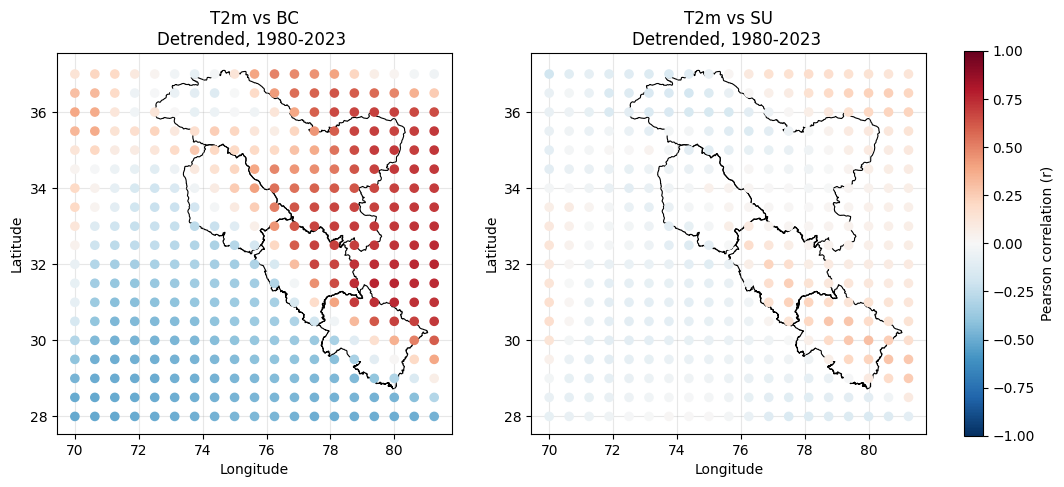

In [155]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)

for ax, aerosol_name in zip(axes, ["BC", "SU"]):

    # --------------------------------------------------------
    # Plot NWH political boundaries in the background
    # --------------------------------------------------------
    nwh.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        zorder=1
    )

    # --------------------------------------------------------
    # Select aerosol data
    # --------------------------------------------------------
    data = strong_corr[
        strong_corr["Aerosol"] == aerosol_name
    ]

    # --------------------------------------------------------
    # Plot correlation values
    # --------------------------------------------------------
    scatter = ax.scatter(
        data["lon"],
        data["lat"],
        c=data["Pearson_r"],
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        s=35,
        zorder=2
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_title(
        f"T2m vs {aerosol_name}\n"
        f"Detrended, 1980-2023 "
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    ax.grid(True, alpha=0.3)


# ------------------------------------------------------------
# Common colorbar
# ------------------------------------------------------------
cbar = fig.colorbar(
    scatter,
    ax=axes,
    fraction=0.025,
    pad=0.04
)

cbar.set_label("Pearson correlation (r)")

# plt.tight_layout()
plt.show()

# Correlation between BC and SU

In [156]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

start_year = 1980
end_year = 2023

# Maximum lag in months
max_lag = 12

# Monthly columns: 1980-01 to 2023-12
months = [
    f"{year}-{month:02d}"
    for year in range(start_year, end_year + 1)
    for month in range(1, 13)
]

aerosols = {
    "BC": BC,
    "SU": SU
}

# Aerosol pairs
pairs = [
    ("BC", "SU")
]

results = []

for idx in range(len(BC)):

    lat = BC.loc[idx, "lat"]
    lon = BC.loc[idx, "lon"]

    for aerosol1, aerosol2 in pairs:

        series1 = aerosols[aerosol1].loc[idx, months].values.astype(float)
        series2 = aerosols[aerosol2].loc[idx, months].values.astype(float)

        # Cross-correlation for every lag
        for lag in range(-max_lag, max_lag + 1):

            if lag < 0:
                # aerosol2 leads aerosol1
                x = series1[:lag]
                y = series2[-lag:]

            elif lag > 0:
                # aerosol2 lags aerosol1
                x = series1[lag:]
                y = series2[:-lag]

            else:
                # Zero lag
                x = series1
                y = series2

            # Remove NaNs pairwise
            valid = ~(np.isnan(x) | np.isnan(y))

            x_valid = x[valid]
            y_valid = y[valid]

            if len(x_valid) < 3:
                continue

            r, p = pearsonr(x_valid, y_valid)

            results.append({
                "lat": lat,
                "lon": lon,
                "Pair": f"{aerosol1}-{aerosol2}",
                "Aerosol_1": aerosol1,
                "Aerosol_2": aerosol2,
                "Lag_months": lag,
                "Cross_correlation": r,
                "p-value": p,
                "N": len(x_valid)
            })

cross_corr = pd.DataFrame(results)

print(cross_corr.head())
print("\nTotal results:", len(cross_corr))

    lat   lon   Pair Aerosol_1 Aerosol_2  Lag_months  Cross_correlation  \
0  28.0  70.0  BC-SU        BC        SU         -12           0.526785   
1  28.0  70.0  BC-SU        BC        SU         -11           0.492232   
2  28.0  70.0  BC-SU        BC        SU         -10           0.407310   
3  28.0  70.0  BC-SU        BC        SU          -9           0.336391   
4  28.0  70.0  BC-SU        BC        SU          -8           0.291255   

        p-value    N  
0  3.495058e-38  516  
1  6.647817e-33  517  
2  4.031503e-22  518  
3  3.388270e-15  519  
4  1.260966e-11  520  

Total results: 9025


In [158]:
# Find the lag having the strongest absolute correlation
idx_max = (
    cross_corr
    .groupby(["lat", "lon", "Pair"])["Cross_correlation"]
    .apply(lambda x: x.abs().idxmax())
)

max_cross_corr = cross_corr.loc[idx_max.values].copy()

print(max_cross_corr.head())

      lat     lon   Pair Aerosol_1 Aerosol_2  Lag_months  Cross_correlation  \
12   28.0  70.000  BC-SU        BC        SU           0           0.578283   
37   28.0  70.625  BC-SU        BC        SU           0           0.557389   
62   28.0  71.250  BC-SU        BC        SU           0           0.532975   
87   28.0  71.875  BC-SU        BC        SU           0           0.506041   
112  28.0  72.500  BC-SU        BC        SU           0           0.478882   

          p-value    N  
12   1.908695e-48  528  
37   1.983778e-44  528  
62   4.411726e-40  528  
87   1.113058e-35  528  
112  1.273340e-31  528  


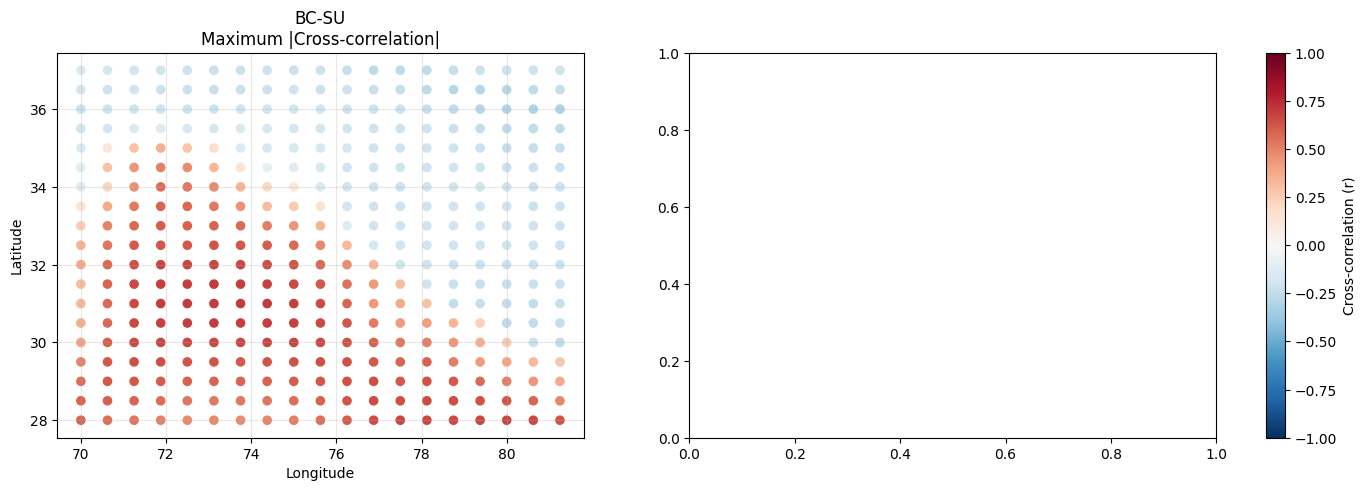

In [162]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 5)
)

for ax, pair in zip(axes, ["BC-SU"]):

    data = max_cross_corr[
        max_cross_corr["Pair"] == pair
    ]

    scatter = ax.scatter(
        data["lon"],
        data["lat"],
        c=data["Cross_correlation"],
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        s=35
    )

    ax.set_title(
        f"{pair}\nMaximum |Cross-correlation|"
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)

cbar = fig.colorbar(
    scatter,
    ax=axes,
    fraction=0.025,
    pad=0.04
)

cbar.set_label("Cross-correlation (r)")

# plt.tight_layout()
plt.show()